# Carleman lifting: Lotka-Volterra predator-prey model

This notebook benchmarks the classical nonlinear model against a finite Carleman lift over a ten-second horizon.

- The nonlinear RK4 recurrence is solved with the repository's full DEER solver. The horizon is continued in short windows so that every Newton solve remains convergent.
- The lifted model is propagated with the repository's zero-order-hold discretization and dense PyTorch associative scan. The lift is restarted from its own predicted first block every two time steps to prevent long-horizon finite-section divergence.

The DOP853 trajectory is used only as an independent numerical reference.


In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.integrate import solve_ivp

repo_root = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "ode_solvers").is_dir()
)
sys.path.insert(0, str(repo_root))

from src.ode_solvers import (
    discretize_lti_zoh,
    linear_affine_scan,
    solve_ode_fixed_step,
)

torch.set_default_dtype(torch.float64)
dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print(f"Repository: {repo_root}")
print(f"Device:     {device}")
print(f"Dtype:      {dtype}")


Repository: /mnt/c/Users/Banaan/Documents/Github/IDK/Para-Seq
Device:     cuda
Dtype:      torch.float64


## Model and finite Carleman system

The nonlinear dynamics are

\[
\dot x=\alpha x-\beta xy,
\qquad
\dot y=\delta xy-\gamma y.
\]

For degree \(k\), use

\[
z_k=[x^k,x^{k-1}y,\ldots,xy^{k-1},y^k]^\mathsf T.
\]

For \(x^{k-j}y^j\),

\[
\frac{d}{dt}(x^{k-j}y^j)
=\bigl((k-j)\alpha-j\gamma\bigr)x^{k-j}y^j
-(k-j)\beta x^{k-j}y^{j+1}
+j\delta x^{k-j+1}y^j.
\]

Thus degree \(k\) couples only to degrees \(k\) and \(k+1\). Terms above truncation order \(N\) are discarded. On each short propagation segment, the finite lift is initialized from the segment's predicted physical state.


In [2]:
alpha = 1.5
beta = 1.0
delta = 0.75
gamma = 1.0

initial_state = np.array([0.3, 0.2], dtype=np.float64)
final_time = 10.0
num_time_points = 513
carleman_order = 10
deer_window_steps = 32
carleman_relift_steps = 2

times = np.linspace(0.0, final_time, num_time_points, dtype=np.float64)


def lotka_volterra_rhs_torch(time, state, control):
    x = state[..., 0]
    y = state[..., 1]
    return torch.stack(
        (alpha * x - beta * x * y, delta * x * y - gamma * y),
        dim=-1,
    )


def lotka_volterra_rhs_scipy(time, state):
    x, y = state
    return np.array(
        [alpha * x - beta * x * y, delta * x * y - gamma * y],
        dtype=np.float64,
    )


In [3]:
def lotka_volterra_carleman_matrix(order):
    offsets = {}
    dimension = 0

    for degree in range(1, order + 1):
        offsets[degree] = dimension
        dimension += degree + 1

    matrix = np.zeros((dimension, dimension), dtype=np.float64)

    for degree in range(1, order + 1):
        row_offset = offsets[degree]

        for y_power in range(degree + 1):
            x_power = degree - y_power
            row = row_offset + y_power
            matrix[row, row] += x_power * alpha - y_power * gamma

            if degree < order:
                next_offset = offsets[degree + 1]
                matrix[row, next_offset + y_power + 1] += -x_power * beta
                matrix[row, next_offset + y_power] += y_power * delta

    return matrix


def lotka_volterra_lift(state, order):
    x = state[0]
    y = state[1]
    values = [
        x ** (degree - y_power) * y**y_power
        for degree in range(1, order + 1)
        for y_power in range(degree + 1)
    ]
    return torch.stack(values) if torch.is_tensor(state) else np.asarray(values)


carleman_matrix = lotka_volterra_carleman_matrix(carleman_order)
sample_state = np.array([0.23, 0.17], dtype=np.float64)
first_block = (
    carleman_matrix @ lotka_volterra_lift(sample_state, carleman_order)
)[:2]
assert np.allclose(first_block, lotka_volterra_rhs_scipy(0.0, sample_state), atol=1e-13)

print(f"Carleman order:       {carleman_order}")
print(f"Lifted dimension:     {carleman_matrix.shape[0]}")
print(f"DEER window steps:    {deer_window_steps}")
print(f"Carleman relift steps:{carleman_relift_steps:5d}")
print("First-block identity verified.")


Carleman order:       10
Lifted dimension:     65
DEER window steps:    32
Carleman relift steps:    2
First-block identity verified.


In [4]:
def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()


def benchmark(function, repeats=3):
    with torch.no_grad():
        result = function()
        synchronize()

        timings = []
        for _ in range(repeats):
            synchronize()
            start = time.perf_counter()
            result = function()
            synchronize()
            timings.append(time.perf_counter() - start)

    return result, float(np.median(timings)), float(np.min(timings))


def reference_trajectory(rhs, initial_state, times):
    solution = solve_ivp(
        rhs,
        (float(times[0]), float(times[-1])),
        np.asarray(initial_state, dtype=np.float64),
        t_eval=times,
        method="DOP853",
        rtol=1e-12,
        atol=1e-14,
    )
    assert solution.success, solution.message
    return solution.y.T


def trajectory_metrics(estimate, reference):
    estimate = np.asarray(estimate, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    pointwise_error = np.linalg.norm(estimate - reference, axis=1)

    return {
        "Maximum error": float(pointwise_error.max()),
        "RMS error": float(np.sqrt(np.mean(pointwise_error**2))),
        "Mean error": float(pointwise_error.mean()),
        "Final error": float(pointwise_error[-1]),
        "Relative L2 error": float(
            np.linalg.norm(estimate - reference) / np.linalg.norm(reference)
        ),
    }


def solve_deer_continuation(rhs, initial_state, times, window_steps):
    state = initial_state
    trajectory = [state[None, :]]
    window_info = []

    for start in range(0, times.numel() - 1, window_steps):
        stop = min(start + window_steps, times.numel() - 1)
        segment, info = solve_ode_fixed_step(
            rhs=rhs,
            x0=state,
            t=times[start : stop + 1],
            method="rk4",
            solver="deer",
            num_iters=20,
            tol=1e-10,
            strict_tol=True,
            stopping_criterion="update",
            initial_guess="constant",
            quasi=False,
            scan_backend="torch",
            include_initial=True,
            return_info=True,
        )
        trajectory.append(segment[1:])
        state = segment[-1]
        window_info.append(info)

    states = torch.cat(trajectory, dim=0)
    info = {
        "num_windows": len(window_info),
        "maximum_iterations": max(item["num_iters"] for item in window_info),
        "total_iterations": sum(item["num_iters"] for item in window_info),
        "maximum_final_merit": max(float(item["final_merit"].cpu()) for item in window_info),
        "maximum_update_error": max(float(item["last_update_error"].cpu()) for item in window_info),
    }
    return states, info


def segmented_linear_trajectory(matrix, lift_function, initial_state, output_dimension, relift_steps):
    matrix = torch.as_tensor(matrix, device=device, dtype=dtype)
    input_matrix = torch.zeros((matrix.shape[0], 1), device=device, dtype=dtype)
    dt = final_time / (num_time_points - 1)
    transition, _ = discretize_lti_zoh(matrix, input_matrix, dt)

    state = torch.as_tensor(initial_state, device=device, dtype=dtype)
    trajectory = [state[None, :]]

    for start in range(0, num_time_points - 1, relift_steps):
        steps = min(relift_steps, num_time_points - 1 - start)
        lifted_state = lift_function(state)
        forcing = torch.zeros((steps, matrix.shape[0]), device=device, dtype=dtype)
        lifted_tail = linear_affine_scan(
            Phi=transition,
            b=forcing,
            x0=lifted_state,
            scan_backend="torch",
        )
        state = lifted_tail[-1, :output_dimension]
        trajectory.append(lifted_tail[:, :output_dimension])

    return torch.cat(trajectory, dim=0)


## Reference, timing benchmark, and solver diagnostics

In [5]:
reference = reference_trajectory(lotka_volterra_rhs_scipy, initial_state, times)
t_tensor = torch.as_tensor(times, device=device, dtype=dtype)
x0_tensor = torch.as_tensor(initial_state, device=device, dtype=dtype)


def solve_nonlinear():
    return solve_deer_continuation(
        rhs=lotka_volterra_rhs_torch,
        initial_state=x0_tensor,
        times=t_tensor,
        window_steps=deer_window_steps,
    )


def solve_carleman():
    return segmented_linear_trajectory(
        matrix=carleman_matrix,
        lift_function=lambda state: lotka_volterra_lift(state, carleman_order),
        initial_state=x0_tensor,
        output_dimension=2,
        relift_steps=carleman_relift_steps,
    )


(nonlinear_states, nonlinear_info), nonlinear_median, nonlinear_minimum = benchmark(solve_nonlinear)
carleman_states, carleman_median, carleman_minimum = benchmark(solve_carleman)

assert torch.isfinite(nonlinear_states).all()
assert torch.isfinite(carleman_states).all()
assert nonlinear_info["maximum_update_error"] <= 1e-9

nonlinear_states = nonlinear_states.cpu().numpy()
carleman_states = carleman_states.cpu().numpy()

timing_table = pd.DataFrame([
    {
        "Method": "Nonlinear RK4 + full DEER continuation",
        "Median time (ms)": 1e3 * nonlinear_median,
        "Minimum time (ms)": 1e3 * nonlinear_minimum,
        "Speedup vs nonlinear": 1.0,
    },
    {
        "Method": f"Segmented linear Carleman N={carleman_order}",
        "Median time (ms)": 1e3 * carleman_median,
        "Minimum time (ms)": 1e3 * carleman_minimum,
        "Speedup vs nonlinear": nonlinear_median / carleman_median,
    },
])
display(timing_table.style.format(precision=4))
print(nonlinear_info)


,Method,Median time (ms),Minimum time (ms),Speedup vs nonlinear
0,Nonlinear RK4 + full DEER continuation,1073.7424,1003.2849,1.0000
1,Segmented linear Carleman N=10,937.3957,905.0363,1.1455


{'num_windows': 16, 'maximum_iterations': 6, 'total_iterations': 71, 'maximum_final_merit': 1.705911707540438e-29, 'maximum_update_error': 4.156230914986736e-11}


## Numerical error analysis

In [6]:
error_table = pd.DataFrame({
    "Nonlinear RK4 + full DEER continuation": trajectory_metrics(nonlinear_states, reference),
    f"Segmented linear Carleman N={carleman_order}": trajectory_metrics(carleman_states, reference),
}).T

assert error_table.loc["Nonlinear RK4 + full DEER continuation", "Maximum error"] < 5e-6
assert error_table.loc[f"Segmented linear Carleman N={carleman_order}", "Maximum error"] < 1e-8

display(error_table.style.format("{:.6e}"))


,Maximum error,RMS error,Mean error,Final error,Relative L2 error
Nonlinear RK4 + full DEER continuation,1.466989e-06,3.643762e-07,2.201605e-07,3.298952e-07,1.036371e-07
Segmented linear Carleman N=10,1.305399e-09,1.865183e-10,6.411168e-11,2.191022e-10,5.305018e-11


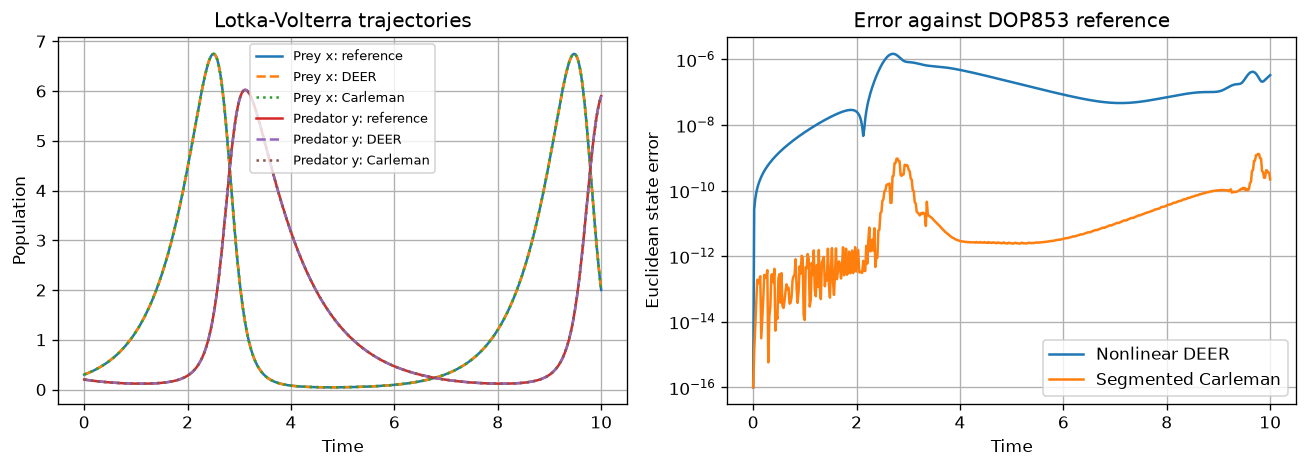

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for state_index, label in enumerate(("Prey x", "Predator y")):
    axes[0].plot(times, reference[:, state_index], label=f"{label}: reference")
    axes[0].plot(times, nonlinear_states[:, state_index], "--", label=f"{label}: DEER")
    axes[0].plot(times, carleman_states[:, state_index], ":", label=f"{label}: Carleman")

nonlinear_error = np.linalg.norm(nonlinear_states - reference, axis=1)
carleman_error = np.linalg.norm(carleman_states - reference, axis=1)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Population")
axes[0].set_title("Lotka-Volterra trajectories")
axes[0].legend(fontsize=8)
axes[1].semilogy(times, np.maximum(nonlinear_error, 1e-16), label="Nonlinear DEER")
axes[1].semilogy(times, np.maximum(carleman_error, 1e-16), label="Segmented Carleman")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Euclidean state error")
axes[1].set_title("Error against DOP853 reference")
axes[1].legend()
plt.tight_layout()
plt.show()


## Truncation-order study

,Order,Lifted dimension,Maximum error,RMS error,Final error
0,4,14,1.381479e-02,2.616603e-03,5.093326e-03
1,6,27,4.302809e-05,7.297927e-06,9.488390e-06
2,8,44,2.148790e-07,3.274737e-08,4.475983e-08
3,10,65,1.305399e-09,1.865183e-10,2.191022e-10


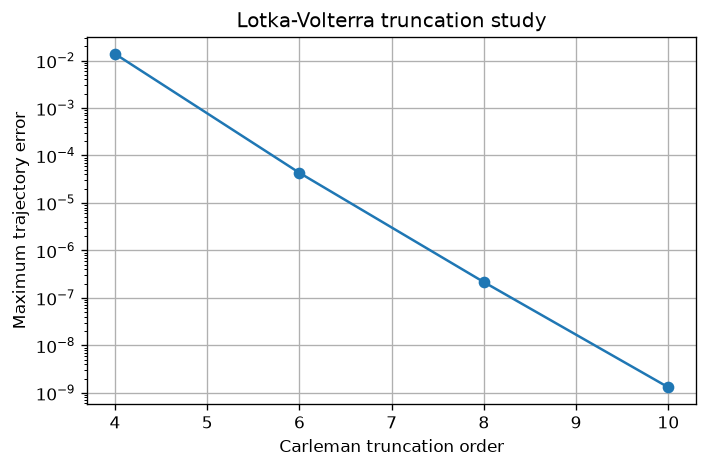

In [8]:
order_records = []
for order in (4, 6, 8, 10):
    matrix = lotka_volterra_carleman_matrix(order)
    estimate = segmented_linear_trajectory(
        matrix=matrix,
        lift_function=lambda state, order=order: lotka_volterra_lift(state, order),
        initial_state=x0_tensor,
        output_dimension=2,
        relift_steps=carleman_relift_steps,
    ).cpu().numpy()
    metrics = trajectory_metrics(estimate, reference)
    order_records.append({
        "Order": order,
        "Lifted dimension": matrix.shape[0],
        "Maximum error": metrics["Maximum error"],
        "RMS error": metrics["RMS error"],
        "Final error": metrics["Final error"],
    })

order_table = pd.DataFrame(order_records)
display(order_table.style.format({
    "Maximum error": "{:.6e}",
    "RMS error": "{:.6e}",
    "Final error": "{:.6e}",
}))
plt.figure(figsize=(6, 4))
plt.semilogy(order_table["Order"], order_table["Maximum error"], "o-")
plt.xlabel("Carleman truncation order")
plt.ylabel("Maximum trajectory error")
plt.title("Lotka-Volterra truncation study")
plt.tight_layout()
plt.show()
